In [ ]:
import os
import zipfile



zip_path = "songs.zip" # Adjust if needed
extract_path = "songszip/"
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("✅ ZIP file extracted successfully.")

✅ ZIP file extracted successfully.

In [ ]:
import codecs

songs_path = os.path.join(extract_path, "songs")  # Path to the extracted songs folder

# Store song pairs
song_pairs = {}

for song_folder in os.listdir(songs_path):
    song_path = os.path.join(songs_path, song_folder)
    if os.path.isdir(song_path):
        malayalam_file = os.path.join(song_path, "malayalam.txt")
        tamil_file = os.path.join(song_path, "tamil.txt")

        if os.path.exists(malayalam_file) and os.path.exists(tamil_file):
            with codecs.open(malayalam_file, "r", encoding="utf-8") as m_file:
                malayalam_lines = m_file.read().strip().split("\n")

            with codecs.open(tamil_file, "r", encoding="utf-8") as t_file:
                tamil_lines = t_file.read().strip().split("\n")

            song_pairs[song_folder] = {
                "malayalam": malayalam_lines,
                "tamil": tamil_lines
            }

print(f"✅ Extracted {len(song_pairs)} song pairs.")


✅ Extracted 90 song pairs.

In [ ]:
aligned_malayalam = []
aligned_tamil = []

for song, data in song_pairs.items():
    malayalam_lines = data["malayalam"]
    tamil_lines = data["tamil"]
    min_length = min(len(malayalam_lines), len(tamil_lines))
    for i in range(min_length):
        aligned_malayalam.append(malayalam_lines[i].strip())
        aligned_tamil.append(tamil_lines[i].strip())

print(f"✅ Final aligned dataset: {len(aligned_malayalam)} Malayalam & {len(aligned_tamil)} Tamil lines")

✅ Final aligned dataset: 3795 Malayalam & 3795 Tamil lines


In [ ]:
import re

def split_to_syllables(text, lang="ml"):
    """
    Splits Malayalam or Tamil words into syllables.
    """
    if lang == "ml":  # Malayalam pattern
        pattern = r'([ക-ഹ][ാ-ൄെ-ൈൊ-ൌം-ഃ]?)'
    elif lang == "ta":  # Tamil pattern
        pattern = r'([க-ஹ][ா-ூெ-ைொ-ௌஂ-ஃ]?)'
    else:
        raise ValueError("Invalid language specified. Use 'ml' or 'ta'.")

    return re.findall(pattern, text)

def extract_rhyme_scheme(text):
    """
    Extracts the last syllable of each line to determine rhyme.
    """
    words = text.split()
    if words:
        last_word = words[-1]
        syllables = split_to_syllables(last_word)
        return "".join(syllables) if syllables else last_word
    return ""

def extract_word_boundaries(text):
  """
    Marks word boundaries using special symbols.
    """
    return " | ".join(text.split())

def extract_features(texts, lang="ml"):
    """
    Extracts syllables, syllable count, rhyme scheme, and word boundaries.
    """
    features = []
    for line in texts:
        words = line.split()
        syllable_list = [split_to_syllables(word, lang) for word in words]
        total_syllables = sum(len(syl) for syl in syllable_list)
        rhyme_scheme = extract_rhyme_scheme(line)
        word_boundaries = extract_word_boundaries(line)

        features.append({
            "line": line,
            "syllables": syllable_list,
            "syllable_count": total_syllables,
            "rhyme_scheme": rhyme_scheme,
            "word_boundaries": word_boundaries
        })

    return features

# Extract features for Malayalam & Tamil
malayalam_features = extract_features(aligned_malayalam, lang="ml")
tamil_features = extract_features(aligned_tamil, lang="ta")

print(f"✅ Extracted features for {len(malayalam_features)} Malayalam & {len(tamil_features)} Tamil lines.")

# Display some extracted features
for i, feature in enumerate(malayalam_features[:5]):  # Show first 5 examples
    print(f"🔹 Malayalam Line {i+1}: {feature['line']}")
    print(f"   Syllables: {feature['syllables']}")
    print(f"   Syllable Count: {feature['syllable_count']}")
    print(f"   Rhyme Scheme: {feature['rhyme_scheme']}")
    print(f"   Word Boundaries: {feature['word_boundaries']}\n")

for i, feature in enumerate(tamil_features[:5]):  # Show first 5 examples
    print(f"🔸 Tamil Line {i+1}: {feature['line']}")
    print(f"   Syllables: {feature['syllables']}")
    print(f"   Syllable Count: {feature['syllable_count']}")
    print(f"   Rhyme Scheme: {feature['rhyme_scheme']}")
    print(f"   Word Boundaries: {feature['word_boundaries']}\n")

✅ Extracted features for 3795 Malayalam & 3795 Tamil lines.
🔹 Malayalam Line 1: ഹൃദയത്തിൻ നിറമായ് പ്രണയത്തിൻ ദലമായ്
   Syllables: [['ഹൃ', 'ദ', 'യ', 'ത', 'തി'], ['നി', 'റ', 'മാ', 'യ'], ['പ', 'ര', 'ണ', 'യ', 'ത', 'തി'], ['ദ', 'ല', 'മാ', 'യ']]
   Syllable Count: 19
   Rhyme Scheme: ദലമായ
   Word Boundaries: ഹൃദയത്തിൻ | നിറമായ് | പ്രണയത്തിൻ | ദലമായ്

🔹 Malayalam Line 2: പനിനീർ മലരായ് നിറയൂ
   Syllables: [['പ', 'നി', 'നീ'], ['മ', 'ല', 'രാ', 'യ'], ['നി', 'റ', 'യൂ']]
   Syllable Count: 10
   Rhyme Scheme: നിറയൂ
   Word Boundaries: പനിനീർ | മലരായ് | നിറയൂ

🔹 Malayalam Line 3: നീർമണിയായ് വന്നുതിരും.. അനുരാഗക്കുളിരേ
   Syllables: [['നീ', 'മ', 'ണി', 'യാ', 'യ'], ['വ', 'ന', 'നു', 'തി', 'രു'], ['നു', 'രാ', 'ഗ', 'ക', 'കു', 'ളി', 'രേ']]
   Syllable Count: 17
   Rhyme Scheme: നുരാഗകകുളിരേ
   Word Boundaries: നീർമണിയായ് | വന്നുതിരും.. | അനുരാഗക്കുളിരേ

🔹 Malayalam Line 4: ഈ രാവിനൊരാലിംഗനമേകൂ..
   Syllables: [[], ['രാ', 'വി', 'നൊ', 'രാ', 'ലി', 'ഗ', 'ന', 'മേ', 'കൂ']]
   Syllable Count: 9
   Rhyme Scheme: രാവിനൊരാലിഗനമേകൂ
   Word Boundaries: ഈ | രാവിനൊരാലിംഗനമേകൂ..

🔹 Malayalam Line 5: ആകാശംചൊരിയും നിറതാരങ്ങളുമായി
   Syllables: [['കാ', 'ശം', 'ചൊ', 'രി', 'യു'], ['നി', 'റ', 'താ', 'ര', 'ങ', 'ങ', 'ളു', 'മാ', 'യി']]
   Syllable Count: 14
   Rhyme Scheme: നിറതാരങങളുമായി
   Word Boundaries: ആകാശംചൊരിയും | നിറതാരങ്ങളുമായി

🔸 Tamil Line 1: இதயத்தின் ஒலியாய் பிரபஞ்சத்தின் மணமாய்
   Syllables: [['த', 'ய', 'த', 'தி', 'ன'], ['லி', 'யா', 'ய'], ['பி', 'ர', 'ப', 'ஞ', 'ச', 'த', 'தி', 'ன'], ['ம', 'ண', 'மா', 'ய']]
   Syllable Count: 20
   Rhyme Scheme: மணமாய்
   Word Boundaries: இதயத்தின் | ஒலியாய் | பிரபஞ்சத்தின் | மணமாய்

🔸 Tamil Line 2: கண்ணீர் மலராய் உதிரும்
   Syllables: [['க', 'ண', 'ணீ', 'ர'], ['ம', 'ல', 'ரா', 'ய'], ['தி', 'ரு', 'ம']]
   Syllable Count: 11
   Rhyme Scheme: உதிரும்
   Word Boundaries: கண்ணீர் | மலராய் | உதிரும்

🔸 Tamil Line 3: தேன் மழையாய் வந்துவிழும் என் உயிரின் கனியே
   Syllables: [['தே', 'ன'], ['ம', 'ழை', 'யா', 'ய'], ['வ', 'ந', 'து', 'வி', 'ழு', 'ம'], ['ன'], ['யி', 'ரி', 'ன'], ['க', 'னி', 'யே']]
   Syllable Count: 19
   Rhyme Scheme: கனியே
   Word Boundaries: தேன் | மழையாய் | வந்துவிழும் | என் | உயிரின் | கனியே

🔸 Tamil Line 4: இரவென்கிலும் ஆலிங்கனம் தாராய்
   Syllables: [['ர', 'வெ', 'ன', 'கி', 'லு', 'ம'], ['லி', 'ங', 'க', 'ன', 'ம'], ['தா', 'ரா', 'ய']]
   Syllable Count: 14
   Rhyme Scheme: தாராய்
   Word Boundaries: இரவென்கிலும் | ஆலிங்கனம் | தாராய்

🔸 Tamil Line 5: ஆகாயம் முழுதும் நாம் காலடிகள் பதியும்
   Syllables: [['கா', 'ய', 'ம'], ['மு', 'ழு', 'து', 'ம'], ['நா', 'ம'], ['கா', 'ல', 'டி', 'க', 'ள'], ['ப', 'தி', 'யு', 'ம']]
   Syllable Count: 18
   Rhyme Scheme: பதியும்
   Word Boundaries: ஆகாயம் | முழுதும் | நாம் | காலடிகள் | பதியும்



In [ ]:
%pip install transformers
%pip install sentencepiece
%pip install torch

Requirement already satisfied: transformers in /home/geethu_mscai23/.local/lib/python3.8/site-packages (4.46.3)
Requirement already satisfied: numpy>=1.17 in /home/geethu_mscai23/.local/lib/python3.8/site-packages (from transformers) (1.24.4)
Requirement already satisfied: regex!=2019.12.17 in /home/geethu_mscai23/.local/lib/python3.8/site-packages (from transformers) (2024.11.6)
Requirement already satisfied: packaging>=20.0 in /home/geethu_mscai23/.local/lib/python3.8/site-packages (from transformers) (24.2)
Requirement already satisfied: requests in /usr/lib/python3/dist-packages (from transformers) (2.22.0)
Requirement already satisfied: tqdm>=4.27 in /usr/local/lib/python3.8/dist-packages (from transformers) (4.66.1)
Requirement already satisfied: pyyaml>=5.1 in /usr/lib/python3/dist-packages (from transformers) (5.3.1)
Requirement already satisfied: filelock in /usr/lib/python3/dist-packages (from transformers) (3.0.12)
Requirement already satisfied: tokenizers<0.21,>=0.20 in /home/geethu_mscai23/.local/lib/python3.8/site-packages (from transformers) (0.20.3)
Requirement already satisfied: safetensors>=0.4.1 in /home/geethu_mscai23/.local/lib/python3.8/site-packages (from transformers) (0.5.3)
Requirement already satisfied: huggingface-hub<1.0,>=0.23.2 in /home/geethu_mscai23/.local/lib/python3.8/site-packages (from transformers) (0.30.2)
Requirement already satisfied: typing-extensions>=3.7.4.3 in /home/geethu_mscai23/.local/lib/python3.8/site-packages (from huggingface-hub<1.0,>=0.23.2->transformers) (4.13.2)
Requirement already satisfied: fsspec>=2023.5.0 in /home/geethu_mscai23/.local/lib/python3.8/site-packages (from huggingface-hub<1.0,>=0.23.2->transformers) (2025.3.0)
Note: you may need to restart the kernel to use updated packages.
Requirement already satisfied: sentencepiece in /home/geethu_mscai23/.local/lib/python3.8/site-packages (0.2.0)
Note: you may need to restart the kernel to use updated packages.
Requirement already satisfied: torch in /home/geethu_mscai23/.local/lib/python3.8/site-packages (2.4.1)
Requirement already satisfied: typing-extensions>=4.8.0 in /home/geethu_mscai23/.local/lib/python3.8/site-packages (from torch) (4.13.2)
Requirement already satisfied: nvidia-nccl-cu12==2.20.5; platform_system == "Linux" and platform_machine == "x86_64" in /home/geethu_mscai23/.local/lib/python3.8/site-packages (from torch) (2.20.5)
Requirement already satisfied: nvidia-curand-cu12==10.3.2.106; platform_system == "Linux" and platform_machine == "x86_64" in /home/geethu_mscai23/.local/lib/python3.8/site-packages (from torch) (10.3.2.106)
Requirement already satisfied: nvidia-cublas-cu12==12.1.3.1; platform_system == "Linux" and platform_machine == "x86_64" in /home/geethu_mscai23/.local/lib/python3.8/site-packages (from torch) (12.1.3.1)
Requirement already satisfied: nvidia-cuda-nvrtc-cu12==12.1.105; platform_system == "Linux" and platform_machine == "x86_64" in /home/geethu_mscai23/.local/lib/python3.8/site-packages (from torch) (12.1.105)
Requirement already satisfied: nvidia-nvtx-cu12==12.1.105; platform_system == "Linux" and platform_machine == "x86_64" in /home/geethu_mscai23/.local/lib/python3.8/site-packages (from torch) (12.1.105)
Requirement already satisfied: filelock in /usr/lib/python3/dist-packages (from torch) (3.0.12)
Requirement already satisfied: nvidia-cufft-cu12==11.0.2.54; platform_system == "Linux" and platform_machine == "x86_64" in /home/geethu_mscai23/.local/lib/python3.8/site-packages (from torch) (11.0.2.54)
...
Requirement already satisfied: nvidia-nvjitlink-cu12 in /home/geethu_mscai23/.local/lib/python3.8/site-packages (from nvidia-cusolver-cu12==11.4.5.107; platform_system == "Linux" and platform_machine == "x86_64"->torch) (12.8.93)
Requirement already satisfied: MarkupSafe>=2.0 in /home/geethu_mscai23/.local/lib/python3.8/site-packages (from jinja2->torch) (2.1.5)
Requirement already satisfied: mpmath<1.4,>=1.1.0 in /home/geethu_mscai23/.local/lib/python3.8/site-packages (from sympy->torch) (1.3.0)
Note: you may need to restart the kernel to use updated packages.
Output is truncated. View as a scrollable element or open in a text editor. Adjust cell output s

In [ ]:
from transformers import MBart50Tokenizer

model_name = "facebook/mbart-large-50-many-to-many-mmt"
tokenizer = MBart50Tokenizer.from_pretrained(model_name, src_lang="ml_IN", tgt_lang="ta_IN")

def tokenize_texts(texts):
    return tokenizer(texts, truncation=True, padding="max_length", max_length=128, return_tensors="pt")

malayalam_tokens = tokenize_texts(aligned_malayalam)
tamil_tokens = tokenize_texts(aligned_tamil)

print(f"✅ Tokenized {len(malayalam_tokens['input_ids'])} sentences.")

✅ Tokenized 3795 sentences.


In [ ]:
%pip install scikit-learn
%pip install evaluate

Requirement already satisfied: scikit-learn in /home/geethu_mscai23/.local/lib/python3.8/site-packages (1.3.2)
Requirement already satisfied: scipy>=1.5.0 in /home/geethu_mscai23/.local/lib/python3.8/site-packages (from scikit-learn) (1.10.1)
Requirement already satisfied: threadpoolctl>=2.0.0 in /home/geethu_mscai23/.local/lib/python3.8/site-packages (from scikit-learn) (3.5.0)
Requirement already satisfied: joblib>=1.1.1 in /home/geethu_mscai23/.local/lib/python3.8/site-packages (from scikit-learn) (1.4.2)
Requirement already satisfied: numpy<2.0,>=1.17.3 in /home/geethu_mscai23/.local/lib/python3.8/site-packages (from scikit-learn) (1.24.4)
Note: you may need to restart the kernel to use updated packages.
Requirement already satisfied: evaluate in /home/geethu_mscai23/.local/lib/python3.8/site-packages (0.4.3)
Requirement already satisfied: huggingface-hub>=0.7.0 in /home/geethu_mscai23/.local/lib/python3.8/site-packages (from evaluate) (0.30.2)
Requirement already satisfied: xxhash in /home/geethu_mscai23/.local/lib/python3.8/site-packages (from evaluate) (3.5.0)
Requirement already satisfied: dill in /home/geethu_mscai23/.local/lib/python3.8/site-packages (from evaluate) (0.4.0)
Requirement already satisfied: packaging in /home/geethu_mscai23/.local/lib/python3.8/site-packages (from evaluate) (24.2)
Requirement already satisfied: pandas in /home/geethu_mscai23/.local/lib/python3.8/site-packages (from evaluate) (2.0.3)
Requirement already satisfied: multiprocess in /home/geethu_mscai23/.local/lib/python3.8/site-packages (from evaluate) (0.70.18)
Requirement already satisfied: datasets>=2.0.0 in /home/geethu_mscai23/.local/lib/python3.8/site-packages (from evaluate) (3.1.0)
Requirement already satisfied: tqdm>=4.62.1 in /usr/local/lib/python3.8/dist-packages (from evaluate) (4.66.1)
Requirement already satisfied: requests>=2.19.0 in /usr/lib/python3/dist-packages (from evaluate) (2.22.0)
Requirement already satisfied: numpy>=1.17 in /home/geethu_mscai23/.local/lib/python3.8/site-packages (from evaluate) (1.24.4)
Requirement already satisfied: fsspec[http]>=2021.05.0 in /home/geethu_mscai23/.local/lib/python3.8/site-packages (from evaluate) (2025.3.0)
Requirement already satisfied: pyyaml>=5.1 in /usr/lib/python3/dist-packages (from huggingface-hub>=0.7.0->evaluate) (5.3.1)
Requirement already satisfied: typing-extensions>=3.7.4.3 in /home/geethu_mscai23/.local/lib/python3.8/site-packages (from huggingface-hub>=0.7.0->evaluate) (4.13.2)
Requirement already satisfied: filelock in /usr/lib/python3/dist-packages (from huggingface-hub>=0.7.0->evaluate) (3.0.12)
Requirement already satisfied: tzdata>=2022.1 in /home/geethu_mscai23/.local/lib/python3.8/site-packages (from pandas->evaluate) (2025.2)
Requirement already satisfied: pytz>=2020.1 in /home/geethu_mscai23/.local/lib/python3.8/site-packages (from pandas->evaluate) (2025.2)
Requirement already satisfied: python-dateutil>=2.8.2 in /home/geethu_mscai23/.local/lib/python3.8/site-packages (from pandas->evaluate) (2.9.0.post0)
Requirement already satisfied: pyarrow>=15.0.0 in /home/geethu_mscai23/.local/lib/python3.8/site-packages (from datasets>=2.0.0->evaluate) (17.0.0)
...
Requirement already satisfied: async-timeout<6.0,>=4.0; python_version < "3.11" in /home/geethu_mscai23/.local/lib/python3.8/site-packages (from aiohttp->datasets>=2.0.0->evaluate) (5.0.1)
Requirement already satisfied: propcache>=0.2.0 in /home/geethu_mscai23/.local/lib/python3.8/site-packages (from yarl<2.0,>=1.12.0->aiohttp->datasets>=2.0.0->evaluate) (0.2.0)
Requirement already satisfied: idna>=2.0 in /usr/lib/python3/dist-packages (from yarl<2.0,>=1.12.0->aiohttp->datasets>=2.0.0->evaluate) (2.8)
Note: you may need to restart the kernel to use updated packages.

In [ ]:
%pip install --upgrade numpy>=1.19.5

%pip install --upgrade numpy>=1.19.5

In [ ]:
%pip install sacrebleu

Requirement already satisfied: sacrebleu in /home/geethu_mscai23/.local/lib/python3.8/site-packages (2.5.1)
Requirement already satisfied: colorama in /usr/lib/python3/dist-packages (from sacrebleu) (0.4.3)
Requirement already satisfied: tabulate>=0.8.9 in /home/geethu_mscai23/.local/lib/python3.8/site-packages (from sacrebleu) (0.9.0)
Requirement already satisfied: numpy>=1.17 in /home/geethu_mscai23/.local/lib/python3.8/site-packages (from sacrebleu) (1.24.4)
Requirement already satisfied: portalocker in /home/geethu_mscai23/.local/lib/python3.8/site-packages (from sacrebleu) (3.0.0)
Requirement already satisfied: regex in /home/geethu_mscai23/.local/lib/python3.8/site-packages (from sacrebleu) (2024.11.6)
Requirement already satisfied: lxml in /home/geethu_mscai23/.local/lib/python3.8/site-packages (from sacrebleu) (5.3.2)
Note: you may need to restart the kernel to use updated packages.

In [ ]:
from sklearn.model_selection import KFold
import torch
from transformers import MBartForConditionalGeneration

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
kf = KFold(n_splits=3, shuffle=True, random_state=42)

from evaluate import load
bleu_eval = load("bleu")
ter_eval = load("ter")

for fold, (train_idx, val_idx) in enumerate(kf.split(aligned_malayalam)):
    print(f"\n🔁 Fold {fold+1}")
    model = MBartForConditionalGeneration.from_pretrained(model_name).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5)

    for epoch in range(3):
        model.train()
        total_loss = 0
        for i in train_idx:
            input_ids = malayalam_tokens["input_ids"][i].unsqueeze(0).to(device)
            attention_mask = malayalam_tokens["attention_mask"][i].unsqueeze(0).to(device)
            labels = tamil_tokens["input_ids"][i].unsqueeze(0).to(device)
            optimizer.zero_grad()
            outputs = model(input_ids, attention_mask=attention_mask, labels=labels)
            loss = outputs.loss
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        print(f"Epoch {epoch+1}: Avg Loss = {total_loss/len(train_idx):.4f}")

    model.eval()
    predictions, references = [], []
    for i in val_idx:
        input_ids = tokenizer(aligned_malayalam[i], return_tensors="pt").input_ids.to(device)
        output_ids = model.generate(input_ids, forced_bos_token_id=tokenizer.lang_code_to_id["ta_IN"])
        translated = tokenizer.decode(output_ids[0], skip_special_tokens=True)
        predictions.append(translated)
        references.append([aligned_tamil[i]])

    print("BLEU:", bleu_eval.compute(predictions=predictions, references=references)["bleu"])
    print("TER:", ter_eval.compute(predictions=predictions, references=references)["score"])


🔁 Fold 1
Epoch 1: Avg Loss = 0.3758
Epoch 2: Avg Loss = 0.1732
Epoch 3: Avg Loss = 0.0885
BLEU: 48.12145524643306527
TER: 0.40426041168023

🔁 Fold 2
Epoch 1: Avg Loss = 0.3727
Epoch 2: Avg Loss = 0.1699
Epoch 3: Avg Loss = 0.1508
BLEU: 46.0720410653164306
TER: 0.401115241635688

🔁 Fold 3
Epoch 1: Avg Loss = 0.3738
Epoch 2: Avg Loss = 0.2279
Epoch 3: Avg Loss = 0.1399
BLEU: 47.8935104732156920
TER: 0.3925806451613

*   List item
*   List item



In [ ]:
def translate_text(text, model, tokenizer, src_lang="ml_IN", tgt_lang="ta_IN", device="cuda" if torch.cuda.is_available() else "cpu"):
    tokenizer.src_lang = src_lang
    inputs = tokenizer(text, return_tensors="pt", padding=True, truncation=True, max_length=128).to(device)
    model.to(device)
    with torch.no_grad():
        generated_tokens = model.generate(**inputs, forced_bos_token_id=tokenizer.lang_code_to_id[tgt_lang])
    return tokenizer.batch_decode(generated_tokens, skip_special_tokens=True)[0]

In [ ]:
import os

# Prompt user to paste the file path
input_file = input("Enter the full path of the Malayalam lyrics text file: ").strip()

# Check if file exists
if not os.path.exists(input_file):
    print("❌ File not found. Please check the path and try again.")
else:
    # Read the Malayalam lyrics
    with open(input_file, "r", encoding="utf-8") as f:
        mal_song = f.read().strip().split("\n")

    # Translate each line (ensure your model & tokenizer are loaded)
    translated_lines = [translate_text(line, model, tokenizer) for line in mal_song]
    output_text = "\n".join(translated_lines)

    # Save the translated lyrics
    output_file = "translated_tamil_lyrics2.txt"
    with open(output_file, "w", encoding="utf-8") as f:
        f.write(output_text)

    print(f"✅ Translation complete! Saved to: {os.path.abspath(output_file)}")


✅ Translation complete! Saved to: /home/geethu_mscai23/songs/translated_tamil_lyrics2.txt

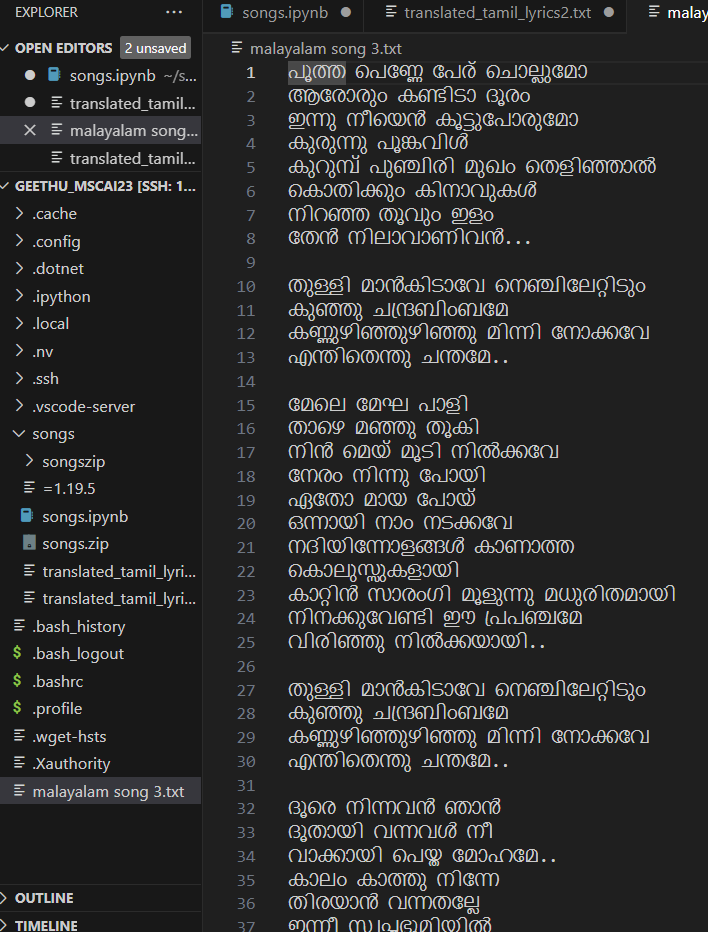

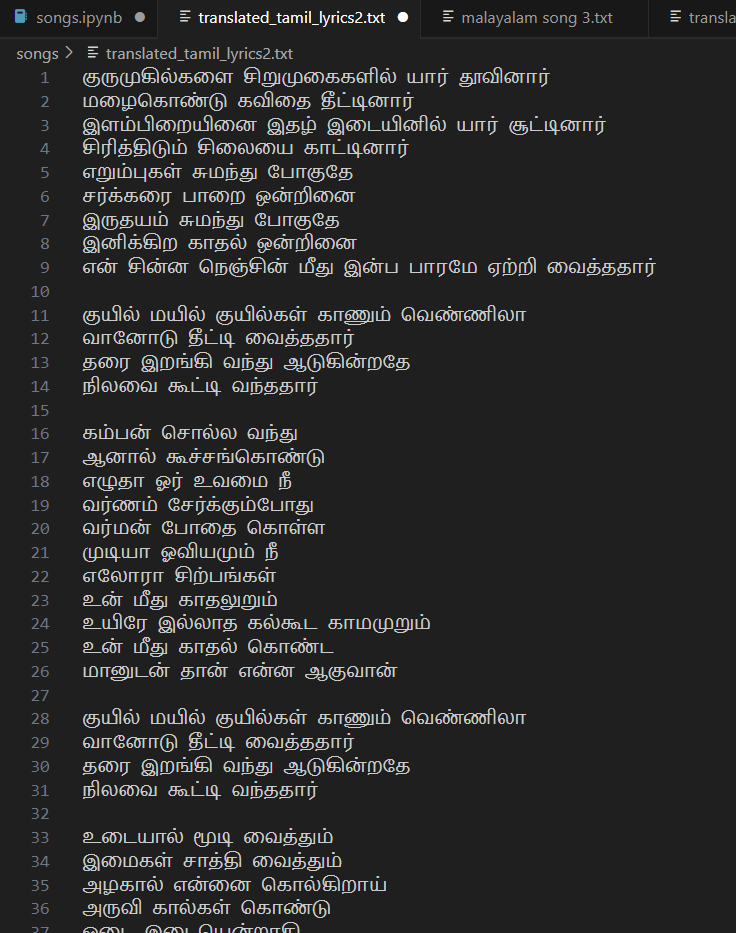